# Multi-Frame vs Bradley-Terry: A Rigorous Comparison

This notebook compares two learning approaches under the **multi-frame data generating process**:

## A) Multi-Frame Learner ("True Model")
- **DGP**: Uses `predict_response_noisy` with τ=τ'=0.25, generating 4 outcome types
- **Policy**: BALD over full 4 outcomes {left, right, indifferent, incomparable}
- **Inference**: Bayesian posterior via hit-and-run MCMC with multi-frame likelihood

## B) Bradley-Terry Baseline ("Strong BT")
- **Inference**: BT logistic model on feature differences, simplex-constrained MAP
  - Uses ONLY decisive outcomes (left/right) in likelihood
  - Ignores indifferent/incomparable in the likelihood (but remembers them for policy)
- **Policy**: BT-consistent uncertainty scoring (Fisher information style)
  - Avoids queries similar to previously rejected ones via rejection memory
  - Does NOT use multi-frame model for query selection

This is a **fair comparison**: BT gets its own optimized query selection without leakage from the multi-frame model.

In [100]:
# ============================================================================
# CELL 1: Imports, Constants, and Helper Utilities
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Constants
# ============================================================================
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)

# Default model parameters
TAU = 0.25           # Indifference threshold
TAU_PRIME = 0.25     # Incomparability threshold  
LAMBDA_X = 1.0       # Feature scaling

# ============================================================================
# Data Structures (from codebase)
# ============================================================================
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

# ============================================================================
# Helper Functions
# ============================================================================
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))."""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))

def phi(query: PairwiseQuery) -> np.ndarray:
    """Feature difference vector: x_left - x_right."""
    return query.patient_left.to_array() - query.patient_right.to_array()

def generate_random_patient_normalized() -> Patient:
    """Generate a random patient with features in [0, 1]."""
    return Patient(
        elderlyDep=np.random.uniform(0, 1),
        lifeYearsGained=np.random.uniform(0, 1),
        obesity=np.random.uniform(0, 1),
        weeklyWorkhours=np.random.uniform(0, 1),
        yearsWaiting=np.random.uniform(0, 1),
    )

def generate_candidate_queries(n_candidates: int = 100) -> List[PairwiseQuery]:
    """Generate candidate queries with normalized features."""
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized()
        right = generate_random_patient_normalized()
        candidates.append(PairwiseQuery(left, right))
    return candidates

print(f"Initialized with {DIM} features: {FEATURE_NAMES}")
print(f"Default thresholds: τ={TAU}, τ'={TAU_PRIME}")

Initialized with 5 features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
Default thresholds: τ=0.25, τ'=0.25


In [101]:
# ============================================================================
# CELL 2: Multi-Frame Model (DGP + Likelihood + Inference)
# ============================================================================
# These functions define the "true" multi-frame model used as the DGP
# and for Bayesian inference.
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active frames.
    Returns: (gaps array, set of active frame indices)
    """
    feature_diff = phi(query)
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score Δ(ω) and intensity r(ω).
    """
    delta_omega = float(np.dot(gaps, weights))
    r_omega = float(sum(weights[j] * abs(gaps[j]) for j in active_frames))
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0
) -> Callable:
    """
    Create noise function for latent margins.
    - Δ gets additive noise
    - r gets multiplicative noise (r̃ = r * exp(ε_r)) to stay positive
    """
    def noise_fn(delta: float, r: float) -> Tuple[float, float]:
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        return delta_tilde, r_tilde
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Generate response from multi-frame model with noise.
    Returns: 'left', 'right', 'indifferent', or 'incomparable'
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    delta_tilde, r_tilde = noise_fn(delta, r)
    
    if r_tilde < tau:
        return 'indifferent'
    if abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_prime * r_tilde else 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    Returns: [p_left, p_right, p_indifferent, p_incomparable]
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        
        if r_tilde < tau:
            counts['indifferent'] += 1
        elif abs(delta_tilde) < tau_prime * r_tilde:
            counts['incomparable'] += 1
        elif delta_tilde >= tau_prime * r_tilde:
            counts['left'] += 1
        else:
            counts['right'] += 1
    
    probs = np.array([counts['left'], counts['right'], 
                      counts['indifferent'], counts['incomparable']]) / n_mc_samples
    return probs


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
) -> float:
    """Compute total log-likelihood of transcript under multi-frame model."""
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


print("Multi-frame model functions defined:")
print("  - predict_response_noisy: DGP for generating responses")
print("  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo")
print("  - compute_transcript_log_likelihood: for MCMC")

Multi-frame model functions defined:
  - predict_response_noisy: DGP for generating responses
  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo
  - compute_transcript_log_likelihood: for MCMC


In [102]:
# ============================================================================
# CELL 3: Multi-Frame MCMC Sampler
# ============================================================================

def hit_and_run_simplex_step(x: np.ndarray) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    dim = len(x)
    d = np.random.randn(dim)
    d = d - d.mean()  # Project onto sum=0
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = np.random.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(ω | transcript) using hit-and-run + MH.
    Returns: (samples array, acceptance rate)
    """
    dim = DIM
    omega = np.ones(dim) / dim
    
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    samples = []
    n_accepted = 0
    
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega)
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        
        if np.log(np.random.rand()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in:
            samples.append(omega.copy())
    
    return np.array(samples), n_accepted / max(1, n_samples)


print("MCMC sampler defined: sample_posterior_hit_and_run")

MCMC sampler defined: sample_posterior_hit_and_run


In [103]:
# ============================================================================
# CELL 6: Multi-Frame BALD Query Selection
# ============================================================================
#
# BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
#
# Uses the full 4-outcome distribution from compute_response_probs_mc.
# This is the multi-frame model's query selection strategy.
# ============================================================================

def multiframe_bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
) -> float:
    """
    Compute BALD score for a query using full 4-outcome model.
    
    BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
    """
    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def multiframe_select_query(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
) -> PairwiseQuery:
    """Select best query according to multi-frame BALD."""
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = multiframe_bald_score(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V
        )
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("Multi-frame BALD functions defined:")
print("  - multiframe_bald_score: BALD over 4 outcomes")
print("  - multiframe_select_query: selects best BALD query")

Multi-frame BALD functions defined:
  - multiframe_bald_score: BALD over 4 outcomes
  - multiframe_select_query: selects best BALD query


In [104]:
# ============================================================================
# CELL 7: Trial Runners for Both Methods
# ============================================================================

def run_multiframe_trial(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    seed: int = None,
) -> Dict:
    """
    Run one multi-frame active learning trial.
    
    This is the "true model":
    - Query selection: BALD over full 4 outcomes
    - Inference: Bayesian posterior via MCMC with multi-frame likelihood
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    
    cos_sims = []
    n_decisive_list = []
    responses = Counter()
    
    # Initial uniform prior samples
    posterior_samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using multi-frame BALD
        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x
        )
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        # Update posterior
        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
        )
        
        # Posterior mean as point estimate
        omega_hat = posterior_samples.mean(axis=0)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'final_estimate': posterior_samples.mean(axis=0),
    }


print("Trial runners defined:")
print("  - run_multiframe_trial: Full Bayesian with 4-way BALD")

Trial runners defined:
  - run_multiframe_trial: Full Bayesian with 4-way BALD


In [105]:
# ============================================================================
# CELL 34: BT Laplace-BALD Trial Runners (Primary BT Implementation)
# ============================================================================
# This is the MAIN BT implementation. Uses Laplace posterior + BALD acquisition.
# Supports forced-choice modes (None, "random", "left") and "until k decisive" variant.

# ============================================================================
# Helper Functions
# ============================================================================

def project_to_simplex(v: np.ndarray) -> np.ndarray:
    """
    Project vector v onto the probability simplex.
    
    Solves: argmin_w ||w - v||^2 s.t. w >= 0, sum(w) = 1
    
    Uses the algorithm from:
    "Efficient Projections onto the l1-Ball for Learning in High Dimensions"
    Duchi et al., 2008
    """
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / np.arange(1, n + 1))[0]
    if len(rho) == 0:
        rho = n - 1
    else:
        rho = rho[-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    w = np.maximum(v - theta, 0)
    return w


def fit_bt_map_simplex(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1.0,
    n_restarts: int = 5,
) -> np.ndarray:
    """
    Fit BT MAP estimate under simplex constraints.
    
    Args:
        phis: (N, dim) array of feature differences phi(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength
        n_restarts: Number of random restarts
    
    Returns:
        omega_map: MAP estimate on simplex
    """
    if len(phis) == 0:
        return np.ones(dim) / dim
    
    def neg_log_posterior(omega):
        logits = phis @ omega
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        omega0 = np.random.dirichlet(np.ones(dim))
        result = minimize(
            neg_log_posterior, omega0, method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


def bt_laplace_covariance(
    phis: np.ndarray,
    omega_map: np.ndarray,
    l2_reg: float = 1.0,
    jitter: float = 1e-6,
) -> np.ndarray:
    """
    Compute Laplace approximation covariance for BT posterior.
    
    Hessian of negative log-posterior:
        H = sum_t p_t(1-p_t) * phi_t phi_t^T + l2_reg * I
    
    Covariance: Sigma = H^{-1}
    """
    dim = len(omega_map)
    
    if len(phis) == 0:
        return np.eye(dim) / l2_reg
    
    logits = phis @ omega_map
    probs = sigmoid(logits)
    weights = probs * (1 - probs)
    H = (phis.T * weights) @ phis + l2_reg * np.eye(dim)
    H += jitter * np.eye(dim)
    
    try:
        sigma = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        sigma = np.linalg.pinv(H)
    
    return sigma


def sample_bt_laplace_posterior(
    omega_map: np.ndarray,
    sigma: np.ndarray,
    n_samples: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Sample from Laplace approximation and project to simplex.
    """
    raw_samples = rng.multivariate_normal(omega_map, sigma, size=n_samples)
    samples = np.array([project_to_simplex(s) for s in raw_samples])
    return samples


def bernoulli_entropy(p: np.ndarray) -> np.ndarray:
    """Compute binary entropy H(p) = -p*log(p) - (1-p)*log(1-p)."""
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)


def bald_bernoulli_from_samples(
    phi_vec: np.ndarray,
    omega_samples: np.ndarray,
) -> float:
    """
    Compute BALD score for a query using BT posterior samples.
    
    BALD = H(E[p]) - E[H(p)]
    where p = sigmoid(omega^T phi) and expectation is over posterior samples.
    """
    logits = omega_samples @ phi_vec
    probs = sigmoid(logits)
    
    mean_p = probs.mean()
    H_mean = bernoulli_entropy(np.array([mean_p]))[0]
    
    entropies = bernoulli_entropy(probs)
    mean_H = entropies.mean()
    
    return H_mean - mean_H


print("BT Laplace-BALD helper functions defined:")
print("  - project_to_simplex, fit_bt_map_simplex, bt_laplace_covariance")
print("  - sample_bt_laplace_posterior, bernoulli_entropy, bald_bernoulli_from_samples")


# ============================================================================
# Main Trial Runners
# ============================================================================

def run_bt_trial_laplace_bald(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    forced_choice: Optional[str] = None,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1.0,
    seed: int = None,
) -> Dict:
    """
    Run BT trial with Laplace posterior approximation and BALD acquisition.
    
    This is the PRIMARY BT implementation, designed to match multi-frame BALD's
    acquisition strategy while using the simpler BT likelihood.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_fn: Noise function for DGP
        tau, tau_prime: DGP thresholds (BT doesn't use these internally)
        lambda_x: Feature scaling
        n_attempts: Number of queries to make
        forced_choice: How to handle non-decisive responses:
            - None: Ignore non-decisive (only use left/right for inference)
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        seed: Random seed
    
    Returns:
        Dict with:
            - cos_sims: Cosine similarity using posterior mean (main metric)
            - cos_sims_map: Cosine similarity using MAP estimate
            - responses: Counter of raw response types
            - forced_responses: Counter after forcing (if forced_choice is set)
            - n_decisive: Number of decisive responses used for inference
            - n_forced: Number of non-decisive responses that were forced
    """
    rng = np.random.default_rng(seed)
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    
    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []
    
    cos_sims_map = []
    cos_sims_mean = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    
    # Initial estimate: uniform prior over the simplex (i.e., equal weights)
    omega_map = np.ones(dim) / dim
    omega_samples = np.tile(omega_map, (n_posterior_samples, 1))
    
    for t in range(n_attempts):
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates)
        
        # Score each candidate with BALD using current posterior samples
        best_query = None
        best_score = -np.inf
        
        for query in candidates:
            phi_vec = phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples)
            if score > best_score:
                best_score = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Query oracle (using multi-frame DGP)
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        
        # Handle forced choice
        if raw_response in ('left', 'right'):
            # Naturally decisive
            response = raw_response
        elif forced_choice is None:
            # No forcing - skip non-decisive for inference
            response = raw_response  # Keep for tracking but don't use for inference
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            n_forced += 1
        elif forced_choice == "left":
            response = "left"
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")
        
        forced_responses[response] += 1
        
        # Update decisive data (only if response is left/right after forcing)
        if response in ('left', 'right'):
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
        
        # Fit MAP and compute Laplace posterior
        if len(phis_decisive) > 0:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            
            omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg)
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg)
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
        else:
            omega_map = np.ones(dim) / dim
            omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
        
        omega_mean = omega_samples.mean(axis=0)
        
        cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
        cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
    
    return {
        'cos_sims': cos_sims_mean,
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'final_estimate': omega_mean,
        'final_map': omega_map,
    }


def run_bt_trial_laplace_bald_until_k(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    k_decisive: int,
    forced_choice: Optional[str] = None,
    max_attempts: int = 500,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1.0,
    seed: int = None,
) -> Dict:
    """
    Run BT trial until k decisive responses are collected.
    
    This variant continues querying until exactly k decisive responses are obtained,
    rather than making a fixed number of attempts. Useful for comparing methods
    at equal amounts of "usable" information.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_fn: Noise function for DGP
        tau, tau_prime: DGP thresholds
        lambda_x: Feature scaling
        k_decisive: Target number of decisive (left/right) responses
        forced_choice: How to handle non-decisive responses:
            - None: Keep querying until k naturally decisive
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        max_attempts: Maximum queries before giving up
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        seed: Random seed
    
    Returns:
        Dict with:
            - cos_sims: Cosine similarity after each attempt
            - n_attempts: Total number of attempts made
            - n_decisive: Number of decisive responses (should equal k_decisive)
            - responses: Counter of raw response types
            - forced_responses: Counter after forcing
            - n_forced: Number of forced responses
            - reached_k: Whether k_decisive was reached
    """
    rng = np.random.default_rng(seed)
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    
    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []
    
    cos_sims_map = []
    cos_sims_mean = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    
    # Initial estimate (uniform)
    omega_map = np.ones(dim) / dim
    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    omega_mean = omega_samples.mean(axis=0)
    
    attempt = 0
    while len(phis_decisive) < k_decisive and attempt < max_attempts:
        attempt += 1
        
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates)
        
        # Score each candidate with BALD
        best_query = None
        best_score = -np.inf
        
        for query in candidates:
            phi_vec = phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples)
            if score > best_score:
                best_score = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Query oracle
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        
        # Handle forced choice
        if raw_response in ('left', 'right'):
            response = raw_response
        elif forced_choice is None:
            response = raw_response
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            n_forced += 1
        elif forced_choice == "left":
            response = "left"
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")
        
        forced_responses[response] += 1
        
        # Update decisive data
        if response in ('left', 'right'):
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
        
        # Fit MAP and compute Laplace posterior
        if len(phis_decisive) > 0:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            
            omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg)
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg)
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
        else:
            omega_map = np.ones(dim) / dim
            omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
        
        omega_mean = omega_samples.mean(axis=0)
        
        cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
        cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
    
    return {
        'cos_sims': cos_sims_mean,
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'n_attempts': attempt,
        'reached_k': len(phis_decisive) >= k_decisive,
        'final_estimate': omega_mean,
        'final_map': omega_map,
    }


print("\nBT Laplace-BALD trial runners defined:")
print("  - run_bt_trial_laplace_bald: Fixed n_attempts, supports forced_choice")
print("     forced_choice options: None (ignore non-decisive), 'random', 'left'")
print("  - run_bt_trial_laplace_bald_until_k: Run until k decisive responses")
print("     Useful for equal-information comparisons")


BT Laplace-BALD helper functions defined:
  - project_to_simplex, fit_bt_map_simplex, bt_laplace_covariance
  - sample_bt_laplace_posterior, bernoulli_entropy, bald_bernoulli_from_samples

BT Laplace-BALD trial runners defined:
  - run_bt_trial_laplace_bald: Fixed n_attempts, supports forced_choice
     forced_choice options: None (ignore non-decisive), 'random', 'left'
  - run_bt_trial_laplace_bald_until_k: Run until k decisive responses
     Useful for equal-information comparisons


# Grid Sweep Experiments

Compare Multi-frame BALD vs BT Laplace-BALD across (τ, τ') grid.

In [106]:
# ============================================================================
# CELL 21: Grid Sweep - Helper Functions
# ============================================================================

from typing import Dict, Any, Optional
import time

def average_curves(results_list: List[Dict], key: str = 'cos_sims', T: int = None) -> Dict:
    """
    Average cosine similarity curves across multiple trial results.
    
    Args:
        results_list: List of trial result dicts, each with 'cos_sims' array
        key: Key to extract from each result (default 'cos_sims')
        T: Expected length (truncates/pads if needed)
    
    Returns:
        Dict with 'mean', 'stderr', 'raw' arrays
    """
    curves = []
    for r in results_list:
        curve = np.array(r[key])
        curves.append(curve)
    
    if T is None:
        T = min(len(c) for c in curves) if curves else 0
    
    padded = []
    for c in curves:
        if len(c) >= T:
            padded.append(c[:T])
        else:
            pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
            pad[:len(c)] = c
            padded.append(pad)
    
    raw = np.array(padded)
    mean = raw.mean(axis=0)
    stderr = raw.std(axis=0) / np.sqrt(len(raw)) if len(raw) > 0 else np.zeros_like(mean)
    
    return {'mean': mean, 'stderr': stderr, 'raw': raw}


def make_fixed_oracle_set(N: int, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 0.2) -> List[np.ndarray]:
    """
    Create a fixed set of oracle weight vectors for reproducible experiments.
    
    Uses sparse Dirichlet (alpha < 1) to create "harder" oracles with peaky weights,
    so cosine similarity starts lower and has room to improve.
    
    Args:
        N: Number of oracles to generate
        dim: Dimension of weight vectors
        oracle_seed: Random seed for reproducibility
        alpha: Dirichlet concentration parameter (< 1 for sparse/peaky weights)
    
    Returns:
        List of N weight vectors on the simplex
    """
    rng = np.random.default_rng(oracle_seed)
    return [rng.dirichlet(alpha * np.ones(dim)) for _ in range(N)]


def run_cell_experiment(
    tau: float,
    tau_prime: float,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    lambda_x: float,
    T: int,
    oracle_weights_list: List[np.ndarray],
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    base_seed: int = 0,
    methods: List[str] = None,
    k_decisive: int = None,
) -> Dict[str, Dict]:
    """
    Run experiment for a single (tau, tau_prime) cell.
    
    Uses a FIXED oracle set passed in from the caller. All methods within a trial
    use the same oracle for fair comparison. The same oracle set is reused across
    all (tau, tau_prime) cells to isolate the effect of thresholds.
    
    Args:
        tau, tau_prime: Thresholds for this cell
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        T: Number of attempts per trial
        oracle_weights_list: Pre-generated list of oracle weight vectors
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC samples for posterior methods
        base_seed: Seed offset for reproducibility
        methods: List of methods to run
        k_decisive: For bt_laplace_bald_k, target number of decisive responses
    
    Returns:
        Dict[method_name] -> {
            'mean': array, 'stderr': array, 'raw': (N, T) array,
            'response_counts': Counter, 'extras': dict,
            'trial_results': list of individual trial result dicts
        }
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']
    
    if k_decisive is None:
        k_decisive = T
    
    N = len(oracle_weights_list)
    
    method_trials = {m: [] for m in methods}
    method_responses = {m: Counter() for m in methods}
    method_extras = {m: {'n_forced': 0, 'n_attempts': 0, 'n_decisive': 0} for m in methods}
    
    for trial in range(N):
        trial_seed = base_seed + trial
        
        # Use fixed oracle from the pre-generated list
        oracle_weights = oracle_weights_list[trial]
        
        for method_index, method in enumerate(methods):
            method_seed = trial_seed + method_index * 100_000
            noise_fn = create_noise_fn(noise_type, scale_delta, scale_r)
            
            if method == 'multiframe':
                result = run_multiframe_trial(
                    oracle_weights, noise_fn, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                    n_posterior_samples=n_posterior_samples, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']
                
            elif method == 'bt_laplace_bald':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice=None, n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_laplace_bald_k':
                result = run_bt_trial_laplace_bald_until_k(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    k_decisive=k_decisive, forced_choice=None, 
                    n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                    seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_attempts'] += result['n_attempts']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_laplace_bald_random':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice="random", n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_laplace_bald_left':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice="left", n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']
    
    # Aggregate results
    results = {}
    for method in methods:
        if method == 'bt_laplace_bald_k':
            avg = average_curves(method_trials[method], key='cos_sims', T=k_decisive)
        else:
            avg = average_curves(method_trials[method], key='cos_sims', T=T)
        avg['response_counts'] = method_responses[method]
        avg['extras'] = method_extras[method]
        avg['trial_results'] = method_trials[method]
        results[method] = avg
    
    return results


print("Grid sweep helper functions defined:")
print("  - average_curves(results_list, key, T)")
print("  - make_fixed_oracle_set(N, dim, oracle_seed, alpha) - creates sparse oracles")
print("  - run_cell_experiment(..., oracle_weights_list) - uses fixed oracle set")


Grid sweep helper functions defined:
  - average_curves(results_list, key, T)
  - make_fixed_oracle_set(N, dim, oracle_seed, alpha) - creates sparse oracles
  - run_cell_experiment(..., oracle_weights_list) - uses fixed oracle set


In [107]:
# ============================================================================
# Sanity Check: Verify Oracle Set Properties
# ============================================================================
# Run this cell to verify the fixed oracle set is "hard" (sparse/peaky)

def check_oracle_set(N: int = 3, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 0.2):
    """Print statistics about the oracle set to verify it's properly sparse."""
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=alpha)
    
    uniform = np.ones(dim) / dim
    cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
    max_weights = [np.max(w) for w in oracle_weights_list]
    
    print(f"Oracle Set Properties (N={N}, dim={dim}, alpha={alpha}, seed={oracle_seed})")
    print("=" * 60)
    print(f"Baseline cosine similarity (vs uniform):")
    print(f"  Mean: {np.mean(cos_baselines):.4f}")
    print(f"  Min:  {np.min(cos_baselines):.4f}")
    print(f"  Max:  {np.max(cos_baselines):.4f}")
    print()
    print(f"Max weight per oracle (measures peakiness):")
    print(f"  Mean: {np.mean(max_weights):.4f}")
    print(f"  Min:  {np.min(max_weights):.4f}")
    print(f"  Max:  {np.max(max_weights):.4f}")
    print()
    print("Sample oracles (first 3):")
    for i, w in enumerate(oracle_weights_list[:3]):
        print(f"  Oracle {i}: {np.round(w, 3)}")
    print()
    
    if np.mean(cos_baselines) < 0.7:
        print("✓ Oracles are sparse - cosine has room to improve!")
    else:
        print("⚠ Oracles may not be sparse enough - consider lower alpha")
    
    return oracle_weights_list

# Run the check with default parameters
print("Checking default oracle set (alpha=0.2):")
_ = check_oracle_set(N=3, alpha=0.2)


Checking default oracle set (alpha=0.2):
Oracle Set Properties (N=3, dim=5, alpha=0.2, seed=2026)
Baseline cosine similarity (vs uniform):
  Mean: 0.5753
  Min:  0.4776
  Max:  0.7549

Max weight per oracle (measures peakiness):
  Mean: 0.7860
  Min:  0.5192
  Max:  0.9348

Sample oracles (first 3):
  Oracle 0: [0.    0.01  0.003 0.053 0.935]
  Oracle 1: [0.519 0.181 0.091 0.008 0.201]
  Oracle 2: [0.05  0.001 0.044 0.001 0.904]

✓ Oracles are sparse - cosine has room to improve!


In [108]:
# ============================================================================
# CELL 22: Grid Sweep - Main Function
# ============================================================================

def run_grid_sweep(
    taus: List[float],
    tau_primes: List[float],
    dim: int = DIM,
    T: int = 20,
    N: int = 3,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    lambda_x: float = 1.0,
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    methods: List[str] = None,
    k_decisive: int = None,
    seed: int = 42,
    oracle_seed: int = 2026,
    oracle_alpha: float = 0.2,
    verbose: bool = True,
) -> Dict[tuple, Dict[str, Dict]]:
    """
    Run grid sweep experiment over (tau, tau_prime) pairs.
    
    Uses a FIXED oracle set across all cells to isolate the effect of (tau, tau_prime).
    Oracles are sampled from sparse Dirichlet (alpha < 1) for harder learning problems.
    
    Args:
        taus: List of tau values for grid
        tau_primes: List of tau_prime values for grid
        dim: Dimension of weight vector
        T: Attempts per trial
        N: Number of trials (same oracles reused across all cells)
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC/Laplace samples
        methods: Methods to compare
        k_decisive: For bt_laplace_bald_k, target decisive count
        seed: Base random seed for method randomness
        oracle_seed: Seed for oracle generation (fixed across cells)
        oracle_alpha: Dirichlet concentration (< 1 for sparse/peaky oracles)
        verbose: Print progress
    
    Returns:
        results: Dict[(tau, tau_prime)] -> Dict[method] -> result dict
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']
    
    if k_decisive is None:
        k_decisive = T
    
    # Create fixed oracle set ONCE for the entire grid sweep
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=oracle_alpha)
    
    if verbose:
        # Sanity check: show oracle statistics
        uniform = np.ones(dim) / dim
        cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
        max_weights = [np.max(w) for w in oracle_weights_list]
        print(f"Fixed oracle set (N={N}, alpha={oracle_alpha}, seed={oracle_seed}):")
        print(f"  Baseline cos_sim (uniform): mean={np.mean(cos_baselines):.3f}, min={np.min(cos_baselines):.3f}, max={np.max(cos_baselines):.3f}")
        print(f"  Max oracle weight: mean={np.mean(max_weights):.3f}, min={np.min(max_weights):.3f}, max={np.max(max_weights):.3f}")
        print()
    
    results = {}
    total_cells = len(taus) * len(tau_primes)
    cell_idx = 0
    start_time = time.time()
    
    # Short names for display
    short_names = {
        'multiframe': 'MF',
        'bt_laplace_bald': 'BT-LB',
        'bt_laplace_bald_k': 'BT-LB-K',
        'bt_laplace_bald_random': 'BT-LB-R',
        'bt_laplace_bald_left': 'BT-LB-L',
    }
    
    if verbose:
        print(f"Grid sweep: {len(taus)}x{len(tau_primes)} = {total_cells} cells")
        print(f"Methods: {methods}")
        print(f"T={T} attempts, N={N} trials per cell (same oracles)")
        if 'bt_laplace_bald_k' in methods:
            print(f"k_decisive={k_decisive} for until-k method")
        print(f"scale_delta={scale_delta}, scale_r={scale_r}")
        print()
    
    for i, tau in enumerate(taus):
        for j, tau_prime in enumerate(tau_primes):
            cell_idx += 1
            
            cell_seed = seed * 10000 + i * 100 + j
            
            if verbose:
                elapsed = time.time() - start_time
                print(f"  Cell {cell_idx}/{total_cells}: tau={tau:.1f}, tau'={tau_prime:.1f} ", end="", flush=True)
            
            cell_results = run_cell_experiment(
                tau=tau,
                tau_prime=tau_prime,
                noise_type=noise_type,
                scale_delta=scale_delta,
                scale_r=scale_r,
                lambda_x=lambda_x,
                T=T,
                oracle_weights_list=oracle_weights_list,
                n_candidates=n_candidates,
                n_posterior_samples=n_posterior_samples,
                base_seed=cell_seed,
                methods=methods,
                k_decisive=k_decisive,
            )
            
            results[(tau, tau_prime)] = cell_results
            
            if verbose:
                method_finals = []
                for m in methods:
                    if m in cell_results and 'mean' in cell_results[m] and len(cell_results[m]['mean']) > 0:
                        final_val = cell_results[m]['mean'][-1]
                        short = short_names.get(m, m[:6])
                        method_finals.append(f"{short}={final_val:.3f}")
                    else:
                        short = short_names.get(m, m[:6])
                        method_finals.append(f"{short}=N/A")
                print(f"-> {', '.join(method_finals)}")
    
    if verbose:
        total_time = time.time() - start_time
        print(f"\nGrid sweep complete in {total_time:.1f}s")
    
    return results


print("Grid sweep function: run_grid_sweep(...)")
print("  Now uses FIXED oracle set across all cells (oracle_seed, oracle_alpha params)")
print("  Default: alpha=0.2 for sparse/peaky oracles")


Grid sweep function: run_grid_sweep(...)
  Now uses FIXED oracle set across all cells (oracle_seed, oracle_alpha params)
  Default: alpha=0.2 for sparse/peaky oracles


In [109]:
# ============================================================================
# CELL 23: Grid Sweep - Plotting Function
# ============================================================================

def plot_grid_sweep(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    methods_to_plot: List[str] = None,
    method_colors: Dict[str, str] = None,
    method_labels: Dict[str, str] = None,
    figsize_per_cell: tuple = (1.2, 1.0),
    show_stderr: bool = False,
    save_path: str = None,
):
    """
    Plot grid of convergence curves.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        T: Number of attempts (x-axis)
        methods_to_plot: Which methods to include (default: all in results)
        method_colors: Dict mapping method name to color
        method_labels: Dict mapping method name to legend label
        figsize_per_cell: (width, height) per subplot cell
        show_stderr: Whether to show shaded stderr bands
        save_path: If provided, save figure to this path
    """
    if methods_to_plot is None:
        # Get methods from first cell
        first_key = list(results.keys())[0]
        methods_to_plot = list(results[first_key].keys())
    
    if method_colors is None:
        method_colors = {
            'multiframe': '#4477AA',   # Blue
            'bt_decisive': '#EE6677',  # Red
            'bt_random': '#228833',    # Green
            'bt_left': '#CCBB44',      # Yellow
        }
    
    if method_labels is None:
        method_labels = {
            'multiframe': 'MF',
            'bt_decisive': 'BT',
            'bt_random': 'BT-R',
            'bt_left': 'BT-L',
        }
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    fig_width = figsize_per_cell[0] * n_cols + 1.5  # Extra for labels/legend
    fig_height = figsize_per_cell[1] * n_rows + 1.0
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), 
                              sharex=True, sharey=True)
    
    # Handle single row/col case
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    attempts = np.arange(1, T + 1)
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            ax = axes[i, j]
            cell_results = results.get((tau, tau_prime), {})
            
            for method in methods_to_plot:
                if method not in cell_results:
                    continue
                    
                data = cell_results[method]
                mean = data['mean']
                color = method_colors.get(method, 'black')
                label = method_labels.get(method, method)
                
                # Plot mean curve
                ax.plot(attempts[:len(mean)], mean, '-', color=color, 
                        linewidth=1.0, label=label)
                
                # Optionally show stderr
                if show_stderr and 'stderr' in data:
                    stderr = data['stderr']
                    ax.fill_between(attempts[:len(mean)], 
                                   mean - stderr, mean + stderr,
                                   color=color, alpha=0.15)
            
            # Subplot formatting
            ax.set_ylim([0, 1.05])
            ax.set_xlim([1, T])
            
            # Only show tick labels on edges
            if i == n_rows - 1:
                ax.set_xlabel('t', fontsize=7)
            else:
                ax.tick_params(labelbottom=False)
            
            if j == 0:
                ax.set_ylabel(f"τ'={tau_prime:.1f}", fontsize=7)
            else:
                ax.tick_params(labelleft=False)
            
            # Title for column (only top row)
            if i == 0:
                ax.set_title(f"τ={tau:.1f}", fontsize=7)
            
            # Smaller ticks
            ax.tick_params(labelsize=5)
            
            # Light grid
            ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    
    # Shared legend at bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(methods_to_plot), 
               fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
    
    # Overall labels
    fig.text(0.5, 0.98, 'τ (indifference threshold)', ha='center', fontsize=9)
    fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center', 
             rotation='vertical', fontsize=9)
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig


def plot_grid_heatmap(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    method: str = 'multiframe',
    metric: str = 'final',  # 'final' or 'auc'
    save_path: str = None,
):
    """
    Plot heatmap of final cosine similarity or AUC across grid.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        method: Which method to plot
        metric: 'final' for final cos_sim, 'auc' for area under curve
        save_path: If provided, save figure
    """
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    grid = np.zeros((n_rows, n_cols))
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            cell_results = results.get((tau, tau_prime), {})
            if method in cell_results:
                mean = cell_results[method]['mean']
                if metric == 'final':
                    grid[i, j] = mean[-1]
                elif metric == 'auc':
                    grid[i, j] = np.mean(mean)  # Simple average as proxy for AUC
            else:
                grid[i, j] = np.nan
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, origin='lower', aspect='auto')
    
    # Labels
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([f"{t:.1f}" for t in taus], fontsize=8)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f"{t:.1f}" for t in tau_primes], fontsize=8)
    
    ax.set_xlabel('τ (indifference)')
    ax.set_ylabel("τ' (incomparability)")
    
    metric_label = "Final cos_sim" if metric == 'final' else "Mean cos_sim"
    ax.set_title(f"{method}: {metric_label}")
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity')
    
    # Add value annotations
    for i in range(n_rows):
        for j in range(n_cols):
            val = grid[i, j]
            if not np.isnan(val):
                color = 'white' if val < 0.5 else 'black'
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                       fontsize=6, color=color)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig, grid


print("Plotting functions defined:")
print("  - plot_grid_sweep(...): 9x9 grid of convergence curves")
print("  - plot_grid_heatmap(...): heatmap of final/mean cos_sim")

Plotting functions defined:
  - plot_grid_sweep(...): 9x9 grid of convergence curves
  - plot_grid_heatmap(...): heatmap of final/mean cos_sim


In [110]:
# ============================================================================
# CELL: Final Grid Sweep - All Methods with Full Data Export
# ============================================================================
# Runs grid sweep with all 5 methods and saves ALL data for reconstruction.

import pandas as pd
import pickle
from datetime import datetime

def run_final_grid_sweep_to_csv(
    taus: List[float] = [0.0, 0.2, 0.4, 0.6, 0.8],
    tau_primes: List[float] = [0.0, 0.2, 0.4, 0.6, 0.8],
    T: int = 20,
    N: int = 3,
    k_decisive: int = None,
    output_prefix: str = "grid_sweep_results",
    oracle_seed: int = 2026,
    oracle_alpha: float = 0.2,
    save_pickle: bool = True,
    **kwargs
) -> tuple:
    """
    Run final grid sweep with all 5 methods and save ALL data.
    
    Uses a FIXED oracle set across all cells for fair comparison.
    Oracles are sparse (alpha < 1) for harder learning problems.
    
    Saves:
        1. {prefix}_{timestamp}.pkl - Full results dict (can reconstruct everything)
        2. {prefix}_trials_{timestamp}.csv - All trials, all timesteps
        3. {prefix}_summary_{timestamp}.csv - Aggregated summary
    
    Methods tested:
        1. multiframe: Full multi-frame BALD
        2. bt_laplace_bald: BT Laplace BALD (ignores non-decisive)
        3. bt_laplace_bald_k: BT Laplace BALD until k decisive
        4. bt_laplace_bald_random: BT Laplace BALD + random forced choice
        5. bt_laplace_bald_left: BT Laplace BALD + deterministic left
    
    Args:
        taus: List of tau values
        tau_primes: List of tau' values  
        T: Attempts per trial
        N: Trials per cell (same oracles reused across all cells)
        k_decisive: Target for until-k method (default: T)
        output_prefix: Prefix for output files
        oracle_seed: Seed for fixed oracle generation
        oracle_alpha: Dirichlet concentration (< 1 for sparse oracles)
        save_pickle: Whether to save pickle file (recommended!)
        **kwargs: Additional args passed to run_grid_sweep
    
    Returns:
        (results_dict, trials_df, summary_df)
    """
    if k_decisive is None:
        k_decisive = T
    
    methods = [
        'multiframe',
        'bt_laplace_bald',
        'bt_laplace_bald_k',
        'bt_laplace_bald_random',
        'bt_laplace_bald_left',
    ]
    
    print("=" * 70)
    print("FINAL GRID SWEEP - 5 Methods Comparison")
    print("=" * 70)
    print(f"Methods: {methods}")
    print(f"Grid: {len(taus)} x {len(tau_primes)} = {len(taus) * len(tau_primes)} cells")
    print(f"T={T} attempts, N={N} trials, k_decisive={k_decisive}")
    print(f"Oracle: seed={oracle_seed}, alpha={oracle_alpha} (fixed across all cells)")
    print("=" * 70)
    print()
    
    # Run the sweep (oracle set is created inside run_grid_sweep)
    results = run_grid_sweep(
        taus=taus,
        tau_primes=tau_primes,
        T=T,
        N=N,
        methods=methods,
        k_decisive=k_decisive,
        oracle_seed=oracle_seed,
        oracle_alpha=oracle_alpha,
        **kwargs
    )
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # =========================================================================
    # 1. Save pickle (full results dict - easiest for reconstruction)
    # =========================================================================
    if save_pickle:
        pickle_filename = f"{output_prefix}_{timestamp}.pkl"
        with open(pickle_filename, 'wb') as f:
            pickle.dump({
                'results': results,
                'taus': taus,
                'tau_primes': tau_primes,
                'T': T,
                'N': N,
                'k_decisive': k_decisive,
                'methods': methods,
                'oracle_seed': oracle_seed,
                'oracle_alpha': oracle_alpha,
                'kwargs': kwargs,
            }, f)
        print(f"\nFull results saved to: {pickle_filename}")
    
    # =========================================================================
    # 2. Create detailed trials DataFrame (one row per trial per timestep)
    # =========================================================================
    trial_rows = []
    for (tau, tau_prime), cell_results in results.items():
        for method, method_result in cell_results.items():
            trial_results = method_result.get('trial_results', [])
            
            for trial_idx, trial in enumerate(trial_results):
                cos_sims = trial.get('cos_sims', [])
                responses = trial.get('responses', Counter())
                
                # One row per timestep
                for t, cos_sim in enumerate(cos_sims):
                    trial_rows.append({
                        'tau': tau,
                        'tau_prime': tau_prime,
                        'method': method,
                        'trial': trial_idx,
                        'timestep': t + 1,
                        'cos_sim': cos_sim,
                    })
                
                # Also store trial-level summary
                trial_rows.append({
                    'tau': tau,
                    'tau_prime': tau_prime,
                    'method': method,
                    'trial': trial_idx,
                    'timestep': -1,  # Marker for summary row
                    'cos_sim': cos_sims[-1] if len(cos_sims) > 0 else np.nan,
                    'n_left': responses.get('left', 0),
                    'n_right': responses.get('right', 0),
                    'n_indifferent': responses.get('indifferent', 0),
                    'n_incomparable': responses.get('incomparable', 0),
                    'n_attempts': len(cos_sims),
                })
    
    trials_df = pd.DataFrame(trial_rows)
    trials_filename = f"{output_prefix}_trials_{timestamp}.csv"
    trials_df.to_csv(trials_filename, index=False)
    print(f"Trial-level data saved to: {trials_filename}")
    
    # =========================================================================
    # 3. Create summary DataFrame (aggregated per cell per method)
    # =========================================================================
    summary_rows = []
    for (tau, tau_prime), cell_results in results.items():
        for method, method_result in cell_results.items():
            mean_curve = method_result['mean']
            stderr_curve = method_result['stderr']
            resp = method_result.get('response_counts', Counter())
            extras = method_result.get('extras', {})
            
            summary_rows.append({
                'tau': tau,
                'tau_prime': tau_prime,
                'method': method,
                'final_cos_sim': mean_curve[-1] if len(mean_curve) > 0 else np.nan,
                'final_stderr': stderr_curve[-1] if len(stderr_curve) > 0 else np.nan,
                'n_left': resp.get('left', 0),
                'n_right': resp.get('right', 0),
                'n_indifferent': resp.get('indifferent', 0),
                'n_incomparable': resp.get('incomparable', 0),
                'n_decisive_total': extras.get('n_decisive', 0),
                'n_forced': extras.get('n_forced', 0),
                'learning_curve_mean': ','.join(f'{v:.4f}' for v in mean_curve),
                'learning_curve_stderr': ','.join(f'{v:.4f}' for v in stderr_curve),
            })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_filename = f"{output_prefix}_summary_{timestamp}.csv"
    summary_df.to_csv(summary_filename, index=False)
    print(f"Summary saved to: {summary_filename}")
    
    # =========================================================================
    # Print summary table
    # =========================================================================
    print("\n" + "=" * 70)
    print("SUMMARY: Final Cosine Similarity by Method")
    print("=" * 70)
    
    pivot = summary_df.pivot_table(
        values='final_cos_sim', 
        index=['tau', 'tau_prime'], 
        columns='method',
        aggfunc='first'
    )
    print(pivot.round(3).to_string())
    
    return results, trials_df, summary_df


def load_results_from_pickle(pickle_path: str) -> Dict:
    """Load results dict from pickle file."""
    with open(pickle_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded results from {pickle_path}")
    print(f"  Grid: {len(data['taus'])} x {len(data['tau_primes'])}")
    print(f"  Methods: {data['methods']}")
    print(f"  T={data['T']}, N={data['N']}")
    if 'oracle_seed' in data:
        print(f"  Oracle: seed={data['oracle_seed']}, alpha={data.get('oracle_alpha', 'N/A')}")
    return data['results'], data


def load_results_from_csv(trials_csv_path: str) -> Dict:
    """
    Reconstruct results dict from trials CSV.
    
    Args:
        trials_csv_path: Path to the _trials_{timestamp}.csv file
    
    Returns:
        results dict compatible with plot_4_convergence_grids
    """
    df = pd.read_csv(trials_csv_path)
    
    # Filter to just timestep data (not summary rows)
    curve_df = df[df['timestep'] > 0].copy()
    
    results = {}
    
    for (tau, tau_prime), cell_group in curve_df.groupby(['tau', 'tau_prime']):
        results[(tau, tau_prime)] = {}
        
        for method, method_group in cell_group.groupby('method'):
            # Get all trials for this method
            trial_curves = []
            for trial_id, trial_group in method_group.groupby('trial'):
                trial_group = trial_group.sort_values('timestep')
                trial_curves.append(trial_group['cos_sim'].values)
            
            # Compute mean and stderr
            T = max(len(c) for c in trial_curves)
            padded = []
            for c in trial_curves:
                if len(c) >= T:
                    padded.append(c[:T])
                else:
                    pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
                    pad[:len(c)] = c
                    padded.append(pad)
            
            raw = np.array(padded)
            mean = raw.mean(axis=0)
            stderr = raw.std(axis=0) / np.sqrt(len(raw)) if len(raw) > 0 else np.zeros_like(mean)
            
            results[(tau, tau_prime)][method] = {
                'mean': mean,
                'stderr': stderr,
                'raw': raw,
            }
    
    print(f"Loaded results from {trials_csv_path}")
    taus = sorted(set(df['tau']))
    tau_primes = sorted(set(df['tau_prime']))
    print(f"  Grid: {len(taus)} x {len(tau_primes)}")
    print(f"  Methods: {df['method'].unique().tolist()}")
    
    return results


print("Grid sweep with full data export defined:")
print("  - run_final_grid_sweep_to_csv(...) -> (results, trials_df, summary_df)")
print("  - load_results_from_pickle(path) -> results dict")
print("  - load_results_from_csv(path) -> results dict")
print()
print("Now uses FIXED oracle set (oracle_seed, oracle_alpha params)")


Grid sweep with full data export defined:
  - run_final_grid_sweep_to_csv(...) -> (results, trials_df, summary_df)
  - load_results_from_pickle(path) -> results dict
  - load_results_from_csv(path) -> results dict

Now uses FIXED oracle set (oracle_seed, oracle_alpha params)


In [111]:
# ============================================================================
# CELL: 4 Grid Convergence Curve Plots - Multiframe vs Each BT Algorithm
# ============================================================================
# Creates 4 separate grid plots showing convergence curves for:
# MF vs each BT variant across all (τ, τ') pairs.

def plot_4_convergence_grids(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    save_prefix: str = None,
    show_stderr: bool = True,
    figsize_per_cell: tuple = (1.2, 1.0),
):
    """
    Create 4 separate grid plots of convergence curves.
    Each plot shows Multiframe vs one BT algorithm.
    
    Args:
        results: Output from run_grid_sweep
        taus: List of tau values
        tau_primes: List of tau' values
        T: Number of attempts (x-axis length)
        save_prefix: If provided, save as {prefix}_mf_vs_{method}.pdf
        show_stderr: Show shaded uncertainty bands
        figsize_per_cell: Size of each subplot
    """
    bt_methods = [
        ('bt_laplace_bald', 'BT (Skips)', '#EE6677'),
        ('bt_laplace_bald_k', 'BT (K-Decisive)', '#228833'),
        ('bt_laplace_bald_random', 'BT (Random Forced Choice)', '#CCBB44'),
        ('bt_laplace_bald_left', 'BT (Deterministic Forced Choice)', '#AA3377'),
    ]
    # Undo LaTeX font backend for matplotlib (restore defaults to avoid missing fonts)
    import matplotlib
    matplotlib.rcParams['text.usetex'] = False
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
    
    # Check which methods are available
    sample_cell = list(results.values())[0]
    available_bt = [(m, l, c) for m, l, c in bt_methods if m in sample_cell]
    
    if 'multiframe' not in sample_cell:
        print("ERROR: multiframe not found in results")
        return
    
    print(f"Creating {len(available_bt)} convergence grid plots...")
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    for bt_method, bt_label, bt_color in available_bt:
        print(f"  Plotting: Multiframe vs {bt_label}...")
        
        fig_width = figsize_per_cell[0] * n_cols + 1.5
        fig_height = figsize_per_cell[1] * n_rows + 1.2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                                  sharex=True, sharey=True)
        
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        if n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        attempts = np.arange(1, T + 1)
        
        for i, tau_prime in enumerate(tau_primes):
            for j, tau in enumerate(taus):
                ax = axes[n_rows - 1 - i, j]  # Flip so τ' increases upward
                cell_results = results.get((tau, tau_prime), {})
                
                # Plot Multiframe
                if 'multiframe' in cell_results:
                    mf_data = cell_results['multiframe']
                    mf_mean = mf_data['mean']
                    ax.plot(attempts[:len(mf_mean)], mf_mean, '-', 
                           color='#4477AA', linewidth=1.2, label='MF')
                    if show_stderr and 'stderr' in mf_data:
                        mf_stderr = mf_data['stderr']
                        ax.fill_between(attempts[:len(mf_mean)],
                                        mf_mean - mf_stderr, mf_mean + mf_stderr,
                                        color='#4477AA', alpha=0.15)
                
                # Plot BT method
                if bt_method in cell_results:
                    bt_data = cell_results[bt_method]
                    bt_mean = bt_data['mean']
                    ax.plot(attempts[:len(bt_mean)], bt_mean, '--',
                           color=bt_color, linewidth=1.2, label=bt_label)
                    if show_stderr and 'stderr' in bt_data:
                        bt_stderr = bt_data['stderr']
                        ax.fill_between(attempts[:len(bt_mean)],
                                        bt_mean - bt_stderr, bt_mean + bt_stderr,
                                        color=bt_color, alpha=0.15)
                
                # Formatting
                ax.set_ylim([0, 1.05])
                ax.set_xlim([1, T])
                ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)
                
                # Labels on edges only
                if n_rows - 1 - i == n_rows - 1:  # Bottom row
                    ax.set_xlabel('Number of Queries', fontsize=7)
                else:
                    ax.tick_params(labelbottom=False)
                
                if j == 0:  # Left column
                    ax.set_ylabel(f"τ'={tau_prime:.1f}", fontsize=7)
                else:
                    ax.tick_params(labelleft=False)
                
                if n_rows - 1 - i == 0:  # Top row
                    ax.set_title(f"τ={tau:.1f}", fontsize=7)
                
                ax.tick_params(labelsize=5)
        
        # Legend at bottom
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=2,
                  fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
        
        # Overall title and labels
        fig.suptitle(f'Multi-frame Model vs {bt_label}: Convergence Curves', fontsize=10, y=0.95)
        fig.text(0.5, 0.9, 'τ (indifference threshold)', ha='center', fontsize=9)
        fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center',
                rotation='vertical', fontsize=9)
        
        plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
        
        # if save_prefix:
        #     save_path = f'{save_prefix}_mf_vs_{bt_method}.pdf'
        #     plt.savefig(save_path, bbox_inches='tight', dpi=150)
        #     print(f"    Saved: {save_path}")
        
        plt.show()
    
    print("\nDone! Created 4 convergence grid plots.")


print("4-way convergence plot function defined: plot_4_convergence_grids(...)")

4-way convergence plot function defined: plot_4_convergence_grids(...)


In [112]:
# ============================================================================
# RUN: Execute Final Grid Sweep
# ============================================================================

# --- OPTION 1: Run new experiment ---
results, trials_df, summary_df = run_final_grid_sweep_to_csv(
    taus=[0.0, 0.2, 0.4, 0.6, 0.8],
    tau_primes=[0.0, 0.2, 0.4, 0.6, 0.8],
    T=20,
    N=2,
    k_decisive=20,
    n_candidates=50,
    n_posterior_samples=200,
    seed=42,
    output_prefix="grid_sweep_5methods"
)

# --- OPTION 2: Load from pickle (recommended) ---
# results, metadata = load_results_from_pickle("grid_sweep_5methods_20260208_213150.pkl")
# taus = metadata['taus']
# tau_primes = metadata['tau_primes']
# T = metadata['T']

# --- OPTION 3: Load from CSV ---
# results = load_results_from_csv("grid_sweep_5methods_trials_20240101_120000.csv")

# --- After loading, make plots ---



FINAL GRID SWEEP - 5 Methods Comparison
Methods: ['multiframe', 'bt_laplace_bald', 'bt_laplace_bald_k', 'bt_laplace_bald_random', 'bt_laplace_bald_left']
Grid: 5 x 5 = 25 cells
T=20 attempts, N=2 trials, k_decisive=20
Oracle: seed=2026, alpha=0.2 (fixed across all cells)

Fixed oracle set (N=2, alpha=0.2, seed=2026):
  Baseline cos_sim (uniform): mean=0.616, min=0.478, max=0.755
  Max oracle weight: mean=0.727, min=0.519, max=0.935

Grid sweep: 5x5 = 25 cells
Methods: ['multiframe', 'bt_laplace_bald', 'bt_laplace_bald_k', 'bt_laplace_bald_random', 'bt_laplace_bald_left']
T=20 attempts, N=2 trials per cell (same oracles)
k_decisive=20 for until-k method
scale_delta=1.0, scale_r=0.0

  Cell 1/25: tau=0.0, tau'=0.0 

-> MF=0.787, BT-LB=0.750, BT-LB-K=0.799, BT-LB-R=0.676, BT-LB-L=0.587
  Cell 2/25: tau=0.0, tau'=0.2 -> MF=0.457, BT-LB=0.817, BT-LB-K=0.584, BT-LB-R=0.697, BT-LB-L=0.711
  Cell 3/25: tau=0.0, tau'=0.4 -> MF=0.877, BT-LB=0.672, BT-LB-K=0.897, BT-LB-R=0.415, BT-LB-L=0.687
  Cell 4/25: tau=0.0, tau'=0.6 -> MF=0.591, BT-LB=0.737, BT-LB-K=0.654, BT-LB-R=0.813, BT-LB-L=0.848
  Cell 5/25: tau=0.0, tau'=0.8 -> MF=0.768, BT-LB=0.695, BT-LB-K=0.639, BT-LB-R=0.782, BT-LB-L=0.753
  Cell 6/25: tau=0.2, tau'=0.0 -> MF=0.824, BT-LB=0.603, BT-LB-K=0.811, BT-LB-R=0.596, BT-LB-L=0.751
  Cell 7/25: tau=0.2, tau'=0.2 -> MF=0.995, BT-LB=0.824, BT-LB-K=0.642, BT-LB-R=0.912, BT-LB-L=0.798
  Cell 8/25: tau=0.2, tau'=0.4 -> MF=0.996, BT-LB=0.799, BT-LB-K=0.721, BT-LB-R=0.801, BT-LB-L=0.507
  Cell 9/25: tau=0.2, tau'=0.6 -> MF=0.999, BT-LB=0.761, BT-LB-K=0.656, BT-LB-R=0.646, BT-LB-L=0.815
  Cell 10/25: tau=0.2, tau'=0.8 -> MF=0.996, BT-LB=0.814, BT-LB-K=0.932, BT-LB-R=0.785, BT-LB-L=0.488
  Cell 11/25: tau=0.

Creating 4 convergence grid plots...
  Plotting: Multiframe vs BT (Skips)...


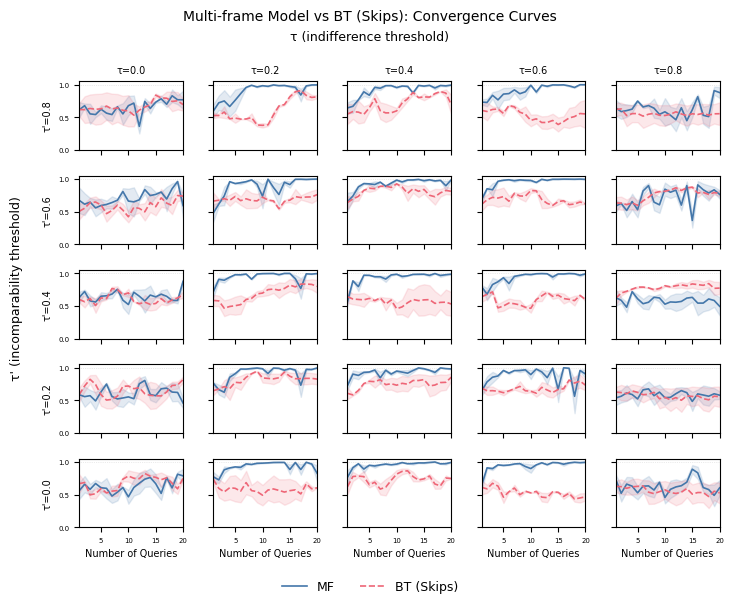

  Plotting: Multiframe vs BT (K-Decisive)...


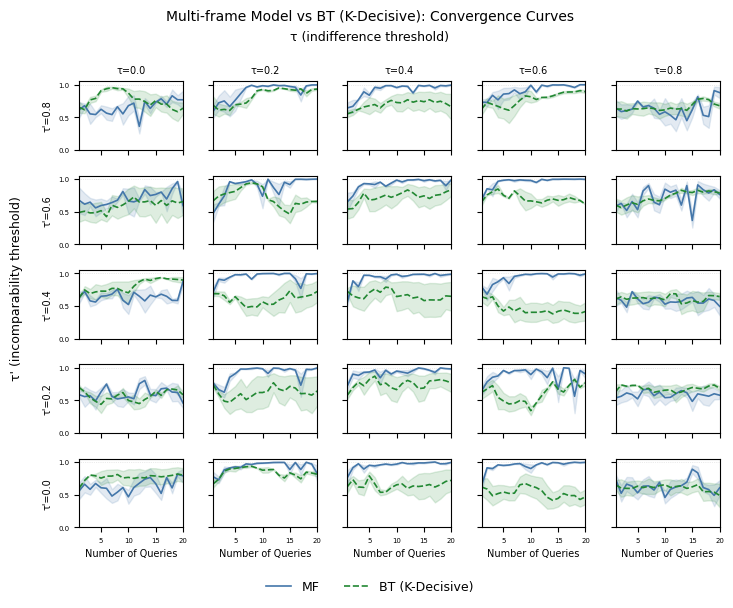

  Plotting: Multiframe vs BT (Random Forced Choice)...


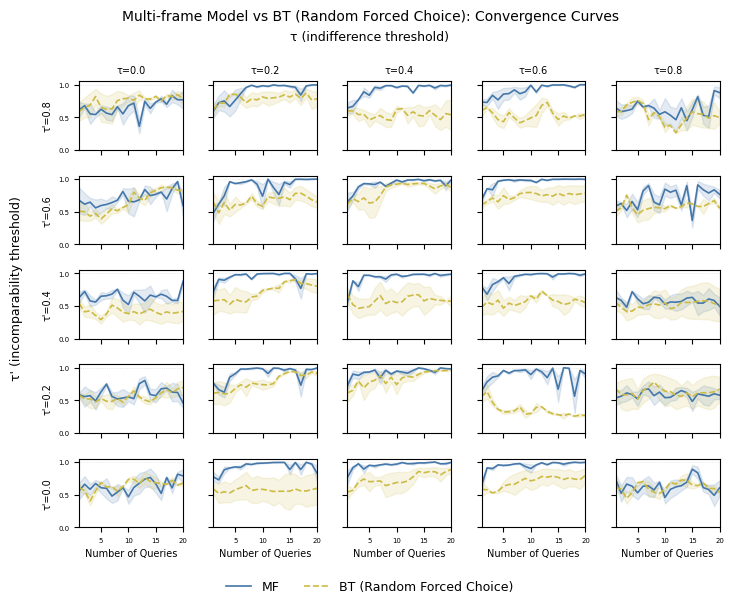

  Plotting: Multiframe vs BT (Deterministic Forced Choice)...


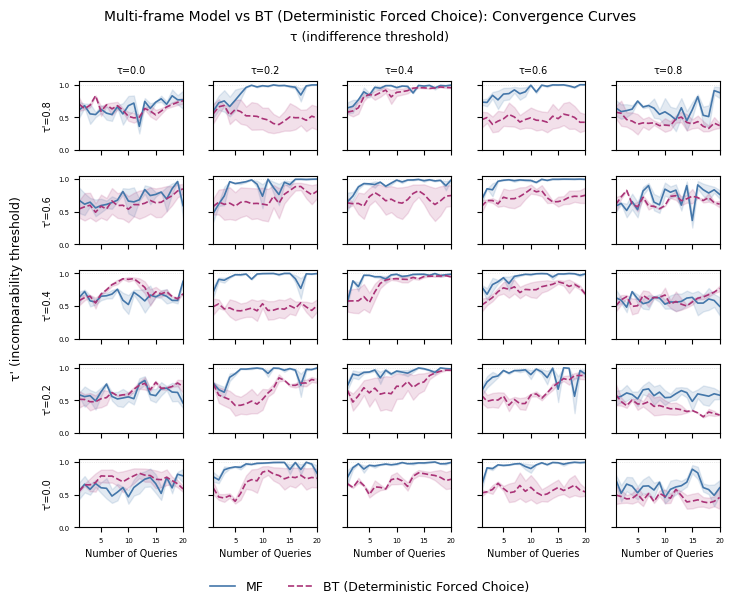


Done! Created 4 convergence grid plots.


In [113]:
plot_4_convergence_grids(
    results,
    taus=[0.0, 0.2, 0.4, 0.6, 0.8],
    tau_primes=[0.0, 0.2, 0.4, 0.6, 0.8],
    T=20,
    save_prefix='convergence_grid',
    show_stderr=True
)